Grupo A: Ingeniería de Datos y ETL (3 personas)

Responsables: María Fernanda Lazón Meza, Luis Méndez Lázaro, Nicolás Alejandro Llerena Silva

Responsabilidades:
* Procesamiento de los 36 archivos JSONL originales.
* Limpieza de datos (manejo de nulos, formatos de fecha ISO8601 y duplicados).
* Estandarización de unidades (conversión de mililitros a galones, metros a kilómetros, etc.).
* Consolidación del dataset final para análisis.



# Parte 1: Ingeniería de Datos y ETL

## Procesamiento de los 36 archivos JSON originales

In [5]:
import zipfile
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
!mv ' volvo.zip' volvo.zip
!unzip -l volvo.zip

In [ ]:
with zipfile.ZipFile('/content/volvo.zip', 'r') as z:
    z.extractall('/content/volvo_data/')

In [ ]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

DATA_DIR = Path('/content/volvo_data/')
files = sorted(DATA_DIR.glob('volvo_datos_*.jsonl'))
print(f'Archivos encontrados: {len(files)}')
for f in files:
    print(f'  - {f.name}')

In [ ]:
# Leer todos los archivos JSONL y consolidar en un solo DF

all_records = []
for fpath in files:
    with open(fpath, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            rec['_source_file'] = fpath.name
            all_records.append(rec)

print(f'Total de registros cargados: {len(all_records):,}')

In [ ]:
# Aplanar los objetos anidados a columnas planas

df = pd.json_normalize(all_records, max_level=2)
print(f'Shape del DataFrame: {df.shape}')
print(f'Columnas totales: {df.shape[1]}')

In [ ]:
df.to_csv('df_jsons.csv', index=False, encoding='utf-8-sig')
print('Guardado: df_jsons.csv')

## Carga del dataset y renombramiento de variables

In [6]:
df = pd.read_csv('df_jsons.csv')
df.head(3)

/tmp/ipykernel_8323/3369594999.py:1: DtypeWarning: Columns (94,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df_jsons.csv')


,vin,createdDateTime,receivedDateTime,hrTotalVehicleDistance,totalEngineHours,grossCombinationVehicleWeight,engineTotalFuelUsed,_source_file,triggerType.triggerType,triggerType.context,...,uptimeData.serviceDistance,uptimeData.engineCoolantTemperature,triggerType.ptoId,snapshotData.volvoGroupSnapshot.driver1WaitingTimeToday,snapshotData.volvoGroupSnapshot.driver1WorkingTimeToday,snapshotData.volvoGroupSnapshot.estimatedDistanceToEmpty,snapshotData.volvoGroupSnapshot.batteryVoltage,snapshotData.volvoGroupSnapshot.trailers,snapshotData.volvoGroupSnapshot.ptoStatus,snapshotData.volvoGroupSnapshot.axleWeights
0,93KXG30DXTE625373,2026-03-22T00:00:08.000Z,2026-03-22T00:00:11.069Z,21732955,2419.601944,35000.0,28987230,volvo_datos_2026-03-22.jsonl,IGNITION_ON,RFMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93KXG30DXTE625373,2026-03-22T00:00:18.000Z,2026-03-22T00:00:19.971Z,21732955,2419.601944,34590.0,28987230,volvo_datos_2026-03-22.jsonl,WITHOUT_ADBLUE,VOLVO GROUP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93KXG30D4TE625371,2026-03-22T00:00:41.000Z,2026-03-22T00:00:44.694Z,22663900,2588.911111,40000.0,30890470,volvo_datos_2026-03-22.jsonl,IGNITION_ON,RFMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(111821, 99)

In [8]:
# Renombramiento

# Definimos el diccionario de traducción a nombres legibles y estandarizados
diccionario_renombrado = {
    "vin": "id_vehiculo",
    "createdDateTime": "fecha_creacion_evento",
    "receivedDateTime": "fecha_recepcion_servidor",
    "hrTotalVehicleDistance": "odometro_total_metros",
    "totalEngineHours": "horas_totales_motor",
    "grossCombinationVehicleWeight": "peso_bruto_combinado",
    "engineTotalFuelUsed": "combustible_total_consumido",
    "_source_file": "archivo_origen_log",
    "triggerType.triggerType": "tipo_evento_disparador",
    "triggerType.context": "contexto_disparador",
    "accumulatedData.durationWheelbaseSpeedOverZero": "tiempo_en_movimiento",
    "accumulatedData.distanceCruiseControlActive": "distancia_con_control_crucero",
    "accumulatedData.durationCruiseControlActive": "tiempo_con_control_crucero",
    "accumulatedData.fuelConsumptionDuringCruiseActive": "combustible_con_control_crucero",
    "accumulatedData.durationWheelbaseSpeedZero": "tiempo_motor_encendido_detenido",
    "accumulatedData.fuelWheelbaseSpeedZero": "combustible_en_ralenti",
    "accumulatedData.fuelWheelbaseSpeedOverZero": "combustible_en_movimiento",
    "accumulatedData.ptoActiveClass": "clase_tiempo_pto_activo",
    "accumulatedData.brakePedalCounterSpeedOverZero": "conteo_frenadas_en_movimiento",
    "accumulatedData.distanceBrakePedalActiveSpeedOverZero": "distancia_recorrida_frenando",
    "accumulatedData.accelerationPedalPositionClass": "histograma_posicion_acelerador",
    "accumulatedData.accelerationClass": "histograma_rangos_aceleracion",
    "accumulatedData.retarderTorqueClass": "histograma_torque_retardador",
    "accumulatedData.drivingWithoutTorqueClass": "histograma_conduccion_por_inercia",
    "accumulatedData.engineTorqueClass": "histograma_torque_motor",
    "accumulatedData.vehicleSpeedClass": "histograma_rangos_velocidad",
    "accumulatedData.engineSpeedClass": "histograma_rpm_motor",
    "accumulatedData.accelerationDuringBrakeClass": "histograma_aceleracion_con_freno",
    "accumulatedData.volvoGroupAccumulated.brakeCount": "conteo_total_frenadas_volvo",
    "accumulatedData.volvoGroupAccumulated.coasting": "tiempo_total_inercia_volvo",
    "accumulatedData.volvoGroupAccumulated.engineOverload": "tiempo_sobrecarga_motor",
    "accumulatedData.volvoGroupAccumulated.engineOverrev": "tiempo_sobre_revolucion_motor",
    "accumulatedData.volvoGroupAccumulated.engineWithinGreenArea": "tiempo_en_zona_verde_rpm",
    "accumulatedData.volvoGroupAccumulated.engineOutOfGreenArea": "tiempo_fuera_zona_verde_rpm",
    "accumulatedData.volvoGroupAccumulated.transmissionModeSeconds": "tiempo_por_modo_transmision",
    "accumulatedData.volvoGroupAccumulated.convoyWeightMeters": "distancia_peso_convoy",
    "accumulatedData.volvoGroupAccumulated.roadOverspeed": "tiempo_exceso_velocidad",
    "accumulatedData.volvoGroupAccumulated.stopCount": "conteo_detenciones_totales",
    "accumulatedData.volvoGroupAccumulated.topGear": "tiempo_en_ultima_marcha",
    "accumulatedData.volvoGroupAccumulated.engineTotalCatalystUsed": "consumo_total_adblue",
    "accumulatedData.volvoGroupAccumulated.withoutCatalyst": "tiempo_operado_sin_adblue",
    "accumulatedData.volvoGroupAccumulated.electricEnergyAuxClass": "clase_energia_electrica_auxiliar",
    "accumulatedData.volvoGroupAccumulated.electricEnergyFromChargingDeviceClass": "clase_energia_carga_externa",
    "accumulatedData.volvoGroupAccumulated.totalElectricEnergyUsedPluggedInIncluded": "total_energia_electrica_consumida",
    "accumulatedData.volvoGroupAccumulated.ptoActiveClass": "clase_pto_activo_volvo",
    "accumulatedData.volvoGroupAccumulated.edriveMode": "modo_conduccion_electrico",
    "accumulatedData.volvoGroupAccumulated.driverAlertWarningMinorCounter": "conteo_alertas_fatiga_menor",
    "accumulatedData.volvoGroupAccumulated.lanekeepingWarningCounter": "conteo_alertas_salida_carril",
    "accumulatedData.volvoGroupAccumulated.totalFuelUsedGaseous": "combustible_gas_total",
    "accumulatedData.volvoGroupAccumulated.fuelConsumptionDuringCruiseActiveGaseous": "combustible_gas_en_crucero",
    "accumulatedData.volvoGroupAccumulated.fuelWheelbasedSpeedZeroGaseous": "combustible_gas_en_ralenti",
    "accumulatedData.volvoGroupAccumulated.fuelWheelbasedSpeedOverZeroGaseous": "combustible_gas_en_movimiento",
    "accumulatedData.volvoGroupAccumulated.driveMode": "perfil_modo_conduccion",
    "accumulatedData.volvoGroupAccumulated.topographyClass": "histograma_topografia_ruta",
    "accumulatedData.volvoGroupAccumulated.durationAirConditioningActive": "tiempo_aire_acondicionado",
    "accumulatedData.volvoGroupAccumulated.antiSlipCounter": "conteo_activaciones_control_traccion",
    "accumulatedData.volvoGroupAccumulated.auxiliaryBrake": "uso_frenos_auxiliares",
    "accumulatedData.volvoGroupAccumulated.brakeAndAutomaticRetarderCounter": "conteo_freno_con_retardador_auto",
    "accumulatedData.volvoGroupAccumulated.brakeAndManualRetarderCounter": "conteo_freno_con_retardador_manual",
    "accumulatedData.volvoGroupAccumulated.durationRetarderActive": "tiempo_retardador_activo",
    "accumulatedData.volvoGroupAccumulated.noBrakeAndAutomaticRetarderCounter": "conteo_solo_retardador_auto",
    "accumulatedData.volvoGroupAccumulated.noBrakeAndManualRetarderCounter": "conteo_solo_retardador_manual",
    "accumulatedData.volvoGroupAccumulated.engineRevolutions": "revoluciones_totales_acumuladas",
    "accumulatedData.volvoGroupAccumulated.brakeAndNoRetarderCounter": "conteo_freno_sin_retardador",
    "accumulatedData.volvoGroupAccumulated.distanceBrakeAndNoRetarder": "distancia_recorrida_freno_sin_retardador",
    "accumulatedData.volvoGroupAccumulated.durationBrakeAndNoRetarder": "tiempo_freno_sin_retardador",
    "snapshotData.gnssPosition.latitude": "posicion_latitud",
    "snapshotData.gnssPosition.longitude": "posicion_longitud",
    "snapshotData.gnssPosition.heading": "rumbo_orientacion_grados",
    "snapshotData.gnssPosition.altitude": "altitud_metros",
    "snapshotData.gnssPosition.speed": "velocidad_gps",
    "snapshotData.gnssPosition.positionDateTime": "fecha_hora_gps",
    "snapshotData.wheelBasedSpeed": "velocidad_ruedas_tacografo",
    "snapshotData.tachographSpeed": "velocidad_tacografo_legal",
    "snapshotData.fuelLevel1": "nivel_combustible_porcentaje",
    "snapshotData.catalystFuelLevel": "nivel_adblue_porcentaje",
    "snapshotData.driver1WorkingState": "estado_laboral_conductor_1",
    "snapshotData.driver2Id.oemDriverIdentification": "id_chofer_coopiloto",
    "snapshotData.driver2WorkingState": "estado_laboral_conductor_2",
    "snapshotData.ambientAirTemperature": "temperatura_ambiental",
    "snapshotData.engineSpeed": "rpm_instantaneas_motor",
    "triggerType.tellTaleInfo.tellTale": "codigo_alerta_tablero",
    "triggerType.tellTaleInfo.state": "estado_alerta_tablero",
    "uptimeData.tellTaleInfo": "logs_alertas_diagnostico",
    "uptimeData.serviceBrakeAirPressureCircuit1": "presion_aire_frenos_circuito_1",
    "uptimeData.serviceBrakeAirPressureCircuit2": "presion_aire_frenos_circuito_2",
    "triggerType.driverId.oemDriverIdentification": "id_chofer_disparador",
    "driver1Id.oemDriverIdentification.oemDriverIdentification": "id_oficial_chofer_principal",
    "triggerType.triggerInfo": "meta_info_disparador",
    "uptimeData.serviceDistance": "distancia_para_proximo_servicio",
    "uptimeData.engineCoolantTemperature": "temperatura_refrigerante_motor",
    "triggerType.ptoId": "id_toma_fuerza_evento",
    "snapshotData.volvoGroupSnapshot.driver1WaitingTimeToday": "tiempo_espera_hoy_chofer_1",
    "snapshotData.volvoGroupSnapshot.driver1WorkingTimeToday": "tiempo_laboral_hoy_chofer_1",
    "snapshotData.volvoGroupSnapshot.estimatedDistanceToEmpty": "autonomia_estimada_restante",
    "snapshotData.volvoGroupSnapshot.batteryVoltage": "voltaje_bateria_instantaneo",
    "snapshotData.volvoGroupSnapshot.trailers": "informacion_remolques_conectados",
    "snapshotData.volvoGroupSnapshot.ptoStatus": "estado_instantaneo_pto",
    "snapshotData.volvoGroupSnapshot.axleWeights": "distribucion_peso_por_ejes"
}

# Renombrar las columnas en tu DataFrame actual (inplace)
df = df.rename(columns=diccionario_renombrado)

# Mostrar columnas para comprobar el cambio
print(f"Columnas renombradas exitosamente: {df.shape[1]}")
df[['id_vehiculo', 'fecha_creacion_evento', 'tipo_evento_disparador', 'combustible_total_consumido']].head()

Columnas renombradas exitosamente: 99


,id_vehiculo,fecha_creacion_evento,tipo_evento_disparador,combustible_total_consumido
0,93KXG30DXTE625373,2026-03-22T00:00:08.000Z,IGNITION_ON,28987230
1,93KXG30DXTE625373,2026-03-22T00:00:18.000Z,WITHOUT_ADBLUE,28987230
2,93KXG30D4TE625371,2026-03-22T00:00:41.000Z,IGNITION_ON,30890470
3,93KXG40G5SE616052,2026-03-21T23:59:16.000Z,TELL_TALE,42899270
4,YV2XG40G8SA365530,2026-03-22T00:01:18.000Z,IGNITION_ON,40803500


In [9]:
# Validación post-rename
columnas_sin_mapear = [c for c in df.columns if c not in diccionario_renombrado.values()]
print(f"Columnas renombradas: {len(diccionario_renombrado)}")
print(f"Columnas totales en df: {df.shape[1]}")
print(f"\nColumnas SIN renombrar ({len(columnas_sin_mapear)}):")
for c in columnas_sin_mapear:
    print(f"  - {c}")

Columnas renombradas: 99
Columnas totales en df: 99

Columnas SIN renombrar (0):


## Inventario y clasificación de variables (qué contiene cada una)

Antes de fijar el diccionario final revisamos columna por columna: tipo de dato, estructura (escalar u objeto JSON anidado), cuántos valores distintos trae y qué porcentaje llega vacío. Sobre esa evidencia decidimos qué variables entran al análisis y cuáles se descartan.

In [10]:
# Inventario de variables: tipo, estructura y contenido real de cada columna
import ast

def estructura_col(serie):
    muestra = serie.dropna()
    if muestra.empty:
        return 'vacía'
    valor = muestra.iloc[0]
    if isinstance(valor, str) and valor[:1] in '[{':
        try:
            obj = ast.literal_eval(valor)
        except (ValueError, SyntaxError):
            return 'texto'
        if isinstance(obj, list):
            return 'lista de objetos' if obj and isinstance(obj[0], dict) else 'lista'
        if isinstance(obj, dict):
            return 'objeto ' + str(list(obj.keys()))
    return 'escalar'

def ejemplo_col(serie, n=80):
    muestra = serie.dropna()
    if muestra.empty:
        return ''
    texto = str(muestra.iloc[0]).replace('\n', ' ')
    return texto[:n] + ('...' if len(texto) > n else '')

inventario = pd.DataFrame({
    'variable': df.columns,
    'tipo': [str(df[c].dtype) for c in df.columns],
    'estructura': [estructura_col(df[c]) for c in df.columns],
    'n_unicos': [df[c].nunique(dropna=True) for c in df.columns],
    'pct_nulos': [round(df[c].isna().mean() * 100, 1) for c in df.columns],
    'ejemplo': [ejemplo_col(df[c]) for c in df.columns],
})

pd.set_option('display.max_colwidth', 85)
pd.set_option('display.max_rows', 120)
inventario

,variable,tipo,estructura,n_unicos,pct_nulos,ejemplo
0,id_vehiculo,object,escalar,37,0.0,93KXG30DXTE625373
1,fecha_creacion_evento,object,escalar,97246,0.0,2026-03-22T00:00:08.000Z
2,fecha_recepcion_servidor,object,escalar,92160,0.0,2026-03-22T00:00:11.069Z
3,odometro_total_metros,int64,escalar,81847,0.0,21732955
4,horas_totales_motor,float64,escalar,27869,0.0,2419.6019444444446
5,peso_bruto_combinado,float64,escalar,1990,69.2,35000.0
6,combustible_total_consumido,int64,escalar,85061,0.0,28987230
7,archivo_origen_log,object,escalar,36,0.0,volvo_datos_2026-03-22.jsonl
8,tipo_evento_disparador,object,escalar,14,0.0,IGNITION_ON
9,contexto_disparador,object,escalar,2,0.0,RFMS


In [11]:
# Clasificación: qué variables entran al análisis y cuáles se descartan

# Una columna no aporta si está 100% vacía o si solo tiene un valor informativo
# (constante). En los objetos, '[]' y '{}' cuentan como "sin información".
valores_vacios = {'[]', '{}', "{'oemDriverIdentification': ''}", ''}

def aporta_info(serie):
    vals = serie.dropna().astype(str)
    vals = vals[~vals.isin(valores_vacios)]
    return vals.nunique() > 1

variables_descartadas = [c for c in df.columns if not aporta_info(df[c])]
variables_utiles = [c for c in df.columns if c not in variables_descartadas]

print(f'Variables útiles: {len(variables_utiles)}')
print(f'Variables descartadas: {len(variables_descartadas)} (constantes o vacías en este dataset)\n')
for c in variables_descartadas:
    print(f'  - {c}')

# Las columnas de conductor llegan vacías y hay eventos DRIVING_WITHOUT_BEING_LOGGEDIN:
# la flota opera sin login de chofer.
print(f'\nUnidad de análisis: {df["id_vehiculo"].nunique()} vehículos '
      f'(no hay identidad de conductor; el análisis por operador no es viable).')

Variables útiles: 79
Variables descartadas: 20 (constantes o vacías en este dataset)

  - histograma_torque_retardador
  - histograma_aceleracion_con_freno
  - clase_energia_electrica_auxiliar
  - clase_energia_carga_externa
  - total_energia_electrica_consumida
  - modo_conduccion_electrico
  - conteo_alertas_salida_carril
  - combustible_gas_total
  - combustible_gas_en_crucero
  - combustible_gas_en_ralenti
  - combustible_gas_en_movimiento
  - estado_laboral_conductor_1
  - id_chofer_coopiloto
  - id_chofer_disparador
  - id_oficial_chofer_principal
  - id_toma_fuerza_evento
  - tiempo_espera_hoy_chofer_1
  - tiempo_laboral_hoy_chofer_1
  - informacion_remolques_conectados
  - distribucion_peso_por_ejes

Unidad de análisis: 37 vehículos (no hay identidad de conductor; el análisis por operador no es viable).


## Limpieza de datos (manejo de nulos, formatos de fecha ISO8601 y duplicados)

In [12]:
# Perfilado general de nulos

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ['columna', 'pct_nulos']
print(f'Columnas con al menos un nulo: {len(null_df)} de {df.shape[1]}')
print(null_df.to_string(index=False))

Columnas con al menos un nulo: 90 de 99
                                 columna  pct_nulos
             id_oficial_chofer_principal 100.000000
              distribucion_peso_por_ejes  99.837240
                   id_toma_fuerza_evento  99.005554
          temperatura_refrigerante_motor  97.561281
         distancia_para_proximo_servicio  97.555915
                   estado_alerta_tablero  97.435187
                   codigo_alerta_tablero  97.435187
                    meta_info_disparador  96.957638
                    id_chofer_disparador  95.203048
          presion_aire_frenos_circuito_1  93.490489
          presion_aire_frenos_circuito_2  93.490489
                logs_alertas_diagnostico  93.470815
             tiempo_laboral_hoy_chofer_1  93.285698
              tiempo_espera_hoy_chofer_1  93.285698
             autonomia_estimada_restante  93.152449
             voltaje_bateria_instantaneo  93.151555
        informacion_remolques_conectados  92.897577
         revoluciones_to

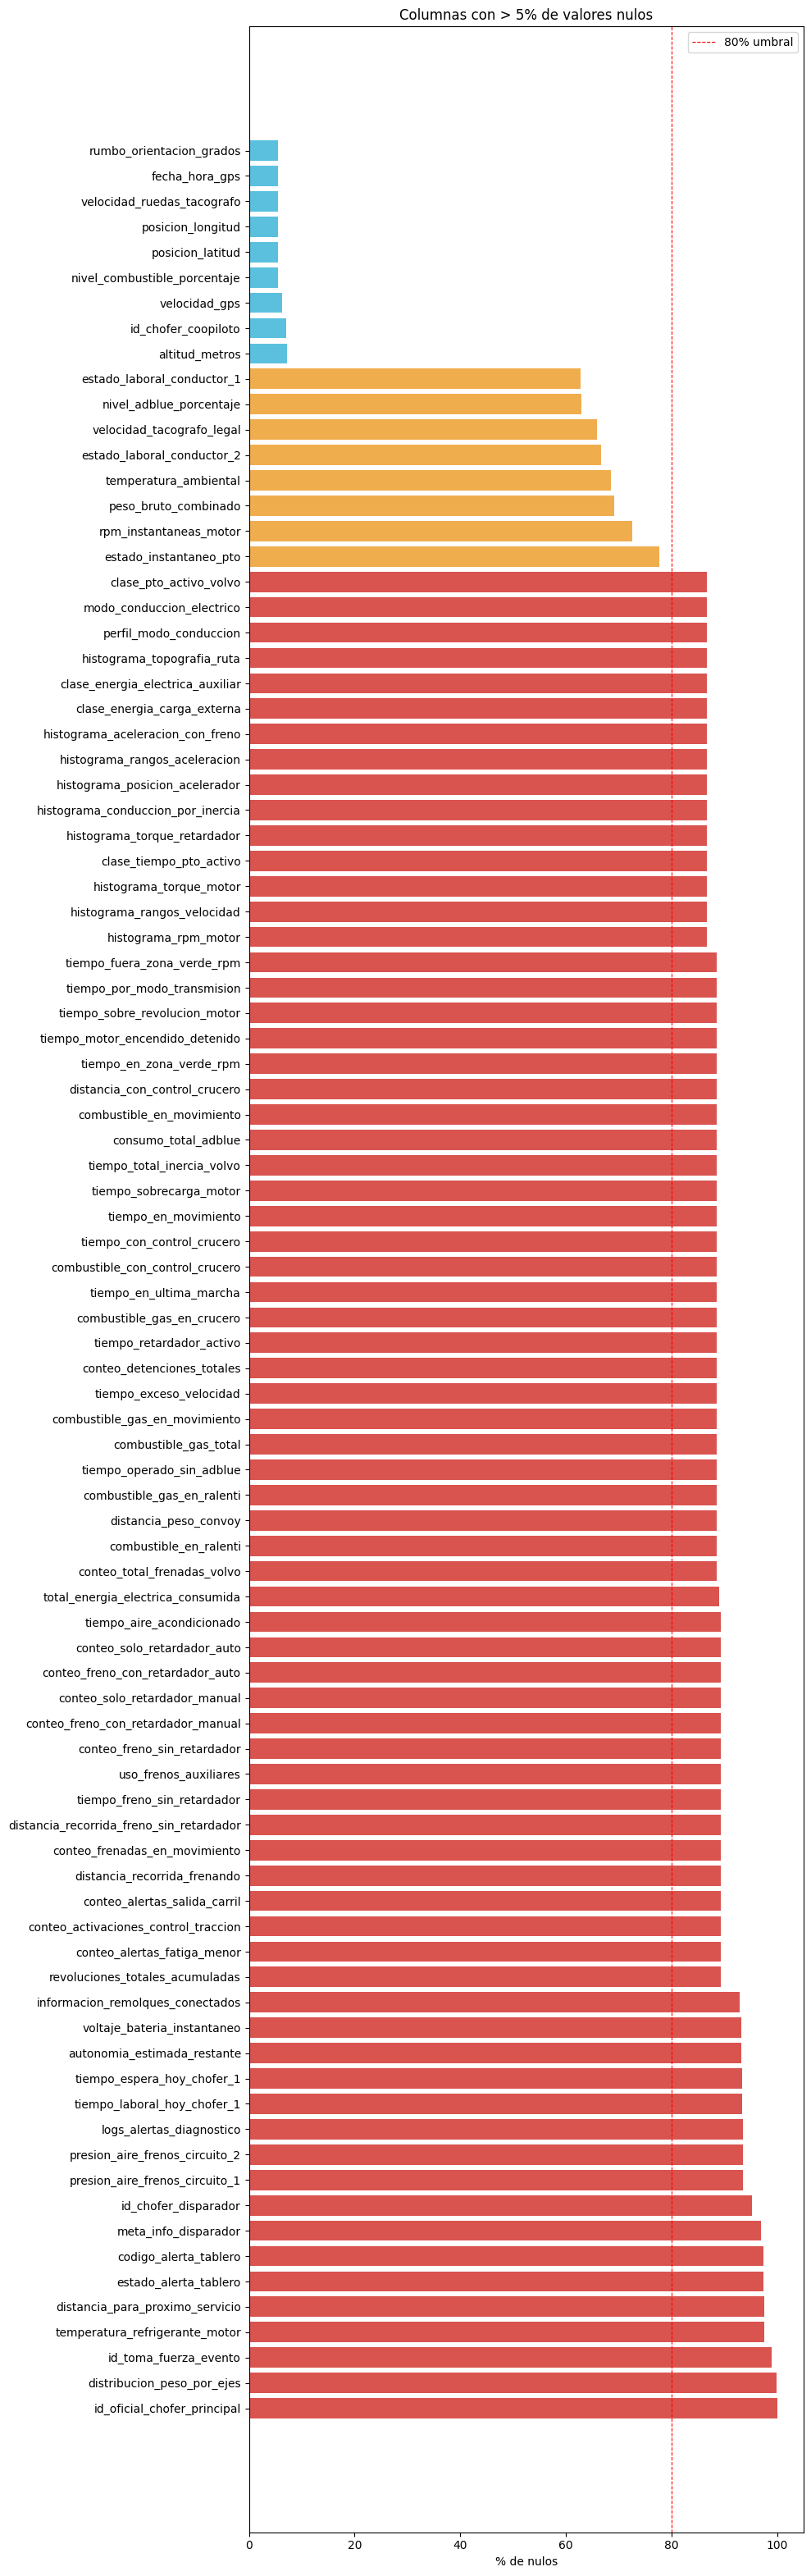

In [13]:
# Visualización: barras horizontales para columnas con >5% de nulos

cols_muchos_nulos = null_df[null_df['pct_nulos'] > 5]
fig, ax = plt.subplots(figsize=(10, max(4, len(cols_muchos_nulos) * 0.35)))
colors = ['#d9534f' if p > 80 else '#f0ad4e' if p > 30 else '#5bc0de'
          for p in cols_muchos_nulos['pct_nulos']]
ax.barh(cols_muchos_nulos['columna'], cols_muchos_nulos['pct_nulos'], color=colors)
ax.axvline(80, color='red', linestyle='--', linewidth=0.8, label='80% umbral')
ax.set_xlabel('% de nulos')
ax.set_title('Columnas con > 5% de valores nulos')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Diagnóstico de nulos: snapshot vs. datos acumulados

# Nombres nuevos de las columnas del bloque acumulado (formato RFMS)
columnas_acumuladas = [
    nuevo for original, nuevo in diccionario_renombrado.items()
    if original.startswith('accumulatedData')]

# El bloque acumulado viaja completo o no viaja; lo marcamos con una columna testigo
df['tiene_datos_acumulados'] = df['combustible_en_movimiento'].notna()
n_acc = df['tiene_datos_acumulados'].sum()

print(f'Columnas del bloque acumulado: {len(columnas_acumuladas)}')
print(f'Filas con bloque acumulado   : {n_acc:,} de {len(df):,} ({n_acc/len(df)*100:.1f}%)')
print('\nReparto del bloque acumulado por tipo de evento:')
print(df.loc[df['tiene_datos_acumulados'], 'tipo_evento_disparador'].value_counts().to_string())
print('\nEl odómetro, las horas de motor y el combustible total llegan en el 100% de los')
print('eventos; el desglose acumulado solo en esa fracción, y NO coincide con TIMER.')
print('Los nulos del bloque son estructurales (cada evento trae snapshot O acumulado),')
print('no errores: no se eliminan, se aíslan en un subset (siguiente celda).')

Columnas del bloque acumulado: 56
Filas con bloque acumulado   : 12,728 de 111,821 (11.4%)

Reparto del bloque acumulado por tipo de evento:
tipo_evento_disparador
IGNITION_ON     4654
TIMER           4057
IGNITION_OFF    4017

El odómetro, las horas de motor y el combustible total llegan en el 100% de los
eventos; el desglose acumulado solo en esa fracción, y NO coincide con TIMER.
Los nulos del bloque son estructurales (cada evento trae snapshot O acumulado),
no errores: no se eliminan, se aíslan en un subset (siguiente celda).


In [15]:
# Subset con datos acumulados (KPIs de consumo, ralentí y eco-conducción)

# El desglose por condición de manejo solo existe donde viaja el bloque acumulado,
# así que filtramos por la columna testigo en lugar de por tipo de evento.
df_acumulado = df[df['tiene_datos_acumulados']].copy()

print(f'Registros con datos acumulados: {len(df_acumulado):>10,}')
print(f'Registros totales: {len(df):>10,}')
print(f'Proporción: {len(df_acumulado)/len(df)*100:.1f}%')
print(f'Vehículos representados: {df_acumulado["id_vehiculo"].nunique()}')

Registros con datos acumulados:     12,728
Registros totales:    111,821
Proporción: 11.4%
Vehículos representados: 37


In [16]:
# Conversión de fechas y creación de variables auxiliares

for col in ['fecha_creacion_evento', 'fecha_recepcion_servidor', 'fecha_hora_gps']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)
df['fecha'] = df['fecha_creacion_evento'].dt.date
df['hora']  = df['fecha_creacion_evento'].dt.hour
df.head(3)

,id_vehiculo,fecha_creacion_evento,fecha_recepcion_servidor,odometro_total_metros,horas_totales_motor,peso_bruto_combinado,combustible_total_consumido,archivo_origen_log,tipo_evento_disparador,contexto_disparador,...,tiempo_espera_hoy_chofer_1,tiempo_laboral_hoy_chofer_1,autonomia_estimada_restante,voltaje_bateria_instantaneo,informacion_remolques_conectados,estado_instantaneo_pto,distribucion_peso_por_ejes,tiene_datos_acumulados,fecha,hora
0,93KXG30DXTE625373,2026-03-22 00:00:08+00:00,2026-03-22 00:00:11.069000+00:00,21732955,2419.601944,35000.0,28987230,volvo_datos_2026-03-22.jsonl,IGNITION_ON,RFMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,2026-03-22,0
1,93KXG30DXTE625373,2026-03-22 00:00:18+00:00,2026-03-22 00:00:19.971000+00:00,21732955,2419.601944,34590.0,28987230,volvo_datos_2026-03-22.jsonl,WITHOUT_ADBLUE,VOLVO GROUP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2026-03-22,0
2,93KXG30D4TE625371,2026-03-22 00:00:41+00:00,2026-03-22 00:00:44.694000+00:00,22663900,2588.911111,40000.0,30890470,volvo_datos_2026-03-22.jsonl,IGNITION_ON,RFMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,2026-03-22,0


In [17]:
# Detección y eliminación de duplicados

# Llave natural: un vehículo no emite dos veces el MISMO tipo de evento en el mismo
# instante. Incluir el tipo de evento evita borrar eventos legítimos que comparten
# timestamp al segundo (p. ej. MOVEMENT e IDLING reportados a la vez).
llave = ['id_vehiculo', 'fecha_creacion_evento', 'tipo_evento_disparador']
n_dupes = df.duplicated(subset=llave, keep='first').sum()

print(f'Filas antes de deduplicar: {len(df):>10,}')
print(f'Duplicados encontrados: {n_dupes:>10,} ({n_dupes/len(df)*100:.2f}%)')

df = df.drop_duplicates(subset=llave, keep='first').reset_index(drop=True)
print(f'Filas después de deduplicar: {len(df):>10,}')

df_acumulado = df[df['tiene_datos_acumulados']].copy()
print(f'\nRegistros con datos acumulados (sin dupes): {len(df_acumulado):,}')

Filas antes de deduplicar:    111,821
Duplicados encontrados:      1,704 (1.52%)
Filas después de deduplicar:    110,117

Registros con datos acumulados (sin dupes): 12,076


## Estandarización de unidades (conversión de mililitros a galones, metros a kilómetros, etc.)

In [18]:
# Estandarización de unidades

ML_TO_GAL = 3785.41 # mililitros -> galones
M_TO_KM = 1000.0 # metros -> kilómetros
SEC_TO_H = 3600.0 # segundos -> horas

unit_conversions = {
    # Combustible (ml -> gal)
    'combustible_total_consumido':              ('ml', ML_TO_GAL, 'gal'),
    'combustible_en_ralenti':                   ('ml', ML_TO_GAL, 'gal'),
    'combustible_en_movimiento':                ('ml', ML_TO_GAL, 'gal'),
    'combustible_con_control_crucero':          ('ml', ML_TO_GAL, 'gal'),
    # Distancia (m -> km)
    'odometro_total_metros':                    ('m',  M_TO_KM,  'km'),
    'distancia_recorrida_frenando':             ('m',  M_TO_KM,  'km'),
    'distancia_para_proximo_servicio':          ('m',  M_TO_KM,  'km'),
    'altitud_metros':                           ('m',  1.0,      'm'),
    'distancia_con_control_crucero':            ('m',  M_TO_KM,  'km'),
    # Tiempo (s -> h)
    'tiempo_motor_encendido_detenido':          ('s',  SEC_TO_H, 'h'),
    'tiempo_en_movimiento':                     ('s',  SEC_TO_H, 'h'),
    'tiempo_con_control_crucero':               ('s',  SEC_TO_H, 'h'),
}

converted = []
for col, (unit_orig, factor, suffix) in unit_conversions.items():
    if col in df.columns:
        new_col = f"{col.replace('_metros', '').replace('_consumido', '')}_{suffix}"
        df[new_col] = pd.to_numeric(df[col], errors='coerce') / factor
        converted.append((col, unit_orig, new_col, suffix))
        print(f'  >  {col}  ->  {new_col}')
    else:
        print(f'  x  Variable "{col}" no encontrada en el dataset')

print(f'\nConversiones realizadas: {len(converted)}')

# Verificación rápida de rangos
col_verificacion = 'combustible_total_gal' if 'combustible_total_gal' in df.columns else 'combustible_total_consumido_gal'

if col_verificacion in df.columns:
    stats = df[col_verificacion].describe(percentiles=[.01,.25,.75,.99])
    print(f'\nVerificación {col_verificacion} (esperado valores de vida acumulada):')
    print(stats.to_string())
    print('Para KPIs del período: usar el subset df_acumulado y restar lecturas consecutivas por vehículo.')

  >  combustible_total_consumido  ->  combustible_total_gal
  >  combustible_en_ralenti  ->  combustible_en_ralenti_gal
  >  combustible_en_movimiento  ->  combustible_en_movimiento_gal
  >  combustible_con_control_crucero  ->  combustible_con_control_crucero_gal
  >  odometro_total_metros  ->  odometro_total_km
  >  distancia_recorrida_frenando  ->  distancia_recorrida_frenando_km
  >  distancia_para_proximo_servicio  ->  distancia_para_proximo_servicio_km
  >  altitud_metros  ->  altitud_m
  >  distancia_con_control_crucero  ->  distancia_con_control_crucero_km
  >  tiempo_motor_encendido_detenido  ->  tiempo_motor_encendido_detenido_h
  >  tiempo_en_movimiento  ->  tiempo_en_movimiento_h
  >  tiempo_con_control_crucero  ->  tiempo_con_control_crucero_h

Conversiones realizadas: 12

Verificación combustible_total_gal (esperado valores de vida acumulada):
count    110117.000000
mean      15682.885492
std       14068.236805
min           0.000000
1%            0.000000
25%        8982.

In [19]:
# Eliminación segura de las columnas originales pre-conversión

# Extraemos la lista de columnas originales que fueron convertidas exitosamente
columnas_a_eliminar = [col for col in unit_conversions.keys() if col in df.columns]

print(f"Filas × Columnas ANTES de eliminar: {df.shape[0]:,} × {df.shape[1]}")

# Eliminamos las columnas viejas en el DataFrame principal 'df'
df = df.drop(columns=columnas_a_eliminar)

print(f"Filas × Columnas DESPUÉS de eliminar: {df.shape[0]:,} × {df.shape[1]}")
print(f"> Se eliminaron con éxito {len(columnas_a_eliminar)} columnas originales obsoletas.")
print(f"Columnas removidas: {columnas_a_eliminar}")

Filas × Columnas ANTES de eliminar: 110,117 × 114
Filas × Columnas DESPUÉS de eliminar: 110,117 × 102
> Se eliminaron con éxito 12 columnas originales obsoletas.
Columnas removidas: ['combustible_total_consumido', 'combustible_en_ralenti', 'combustible_en_movimiento', 'combustible_con_control_crucero', 'odometro_total_metros', 'distancia_recorrida_frenando', 'distancia_para_proximo_servicio', 'altitud_metros', 'distancia_con_control_crucero', 'tiempo_motor_encendido_detenido', 'tiempo_en_movimiento', 'tiempo_con_control_crucero']


In [20]:
# Actualizar el subset acumulado para que herede las unidades convertidas
df_acumulado = df[df['tiene_datos_acumulados']].copy()
print(f"Shape de df_acumulado: {df_acumulado.shape[0]:,} filas × {df_acumulado.shape[1]} columnas")

Shape de df_acumulado: 12,076 filas × 102 columnas


## Consolidación del dataset final para análisis

In [21]:
# Consolidación del dataset final

# Ordenar por vehículo y tiempo — CRÍTICO para cálculo de diferenciales
df = df.sort_values(['id_vehiculo', 'fecha_creacion_evento']).reset_index(drop=True)
df_acumulado = df_acumulado.sort_values(['id_vehiculo', 'fecha_creacion_evento']).reset_index(drop=True)

# Dataset completo (todos los tipos de evento) y subset con datos acumulados
out_full = 'dataset_analitico.csv'
out_acc = 'dataset_acumulado.csv'

df.to_csv(out_full, index=False, encoding='utf-8-sig')
df_acumulado.to_csv(out_acc, index=False, encoding='utf-8-sig')

print(f"dataset_analitico.csv  -> {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"dataset_acumulado.csv  -> {df_acumulado.shape[0]:,} filas × {df_acumulado.shape[1]} columnas")

dataset_analitico.csv  -> 110,117 filas × 102 columnas
dataset_acumulado.csv  -> 12,076 filas × 102 columnas


In [22]:
df.shape

(110117, 102)

In [23]:
print('=' * 60)
print('        RESUMEN DEL ETL — PARTE 1')
print('=' * 60)
print(f'  Dataset completo guardado  : {out_full}')
print(f'  Dataset acumulado guardado : {out_acc}')
print()
print(f'  Shape completo  : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  Shape acumulado : {df_acumulado.shape[0]:,} filas × {df_acumulado.shape[1]} columnas')
print()
fecha_min = pd.to_datetime(df['fecha_creacion_evento']).min()
fecha_max = pd.to_datetime(df['fecha_creacion_evento']).max()
print(f'  Rango de fechas : {fecha_min.date()} → {fecha_max.date()}')
print(f'  Vehículos únicos (IDs) : {df["id_vehiculo"].nunique():,}')
print()
print('  Distribución por tipo_evento_disparador:')
for ttype, cnt in df['tipo_evento_disparador'].value_counts().items():
    print(f'    {ttype:<30} {cnt:>10,}  ({cnt/len(df)*100:.1f}%)')
print()
print('  Pasos ETL realizados:')
print('    1. Lectura y aplanado de 36 archivos JSONL (pd.json_normalize)')
print('    2. Renombramiento de las 99 columnas a nombres legibles en español')
print('    3. Inventario y clasificación (descarte de 20 columnas constantes/vacías)')
print('    4. Conversión de fechas ISO8601 a datetime (UTC)')
print('    5. Subset df_acumulado: bloque RFMS de datos acumulados (no es TIMER)')
print('    6. Deduplicación por (id_vehiculo, fecha_creacion_evento, tipo_evento_disparador)')
print('    7. Estandarización de unidades: ml->gal, m->km, s->h')
print('=' * 60)

        RESUMEN DEL ETL — PARTE 1
  Dataset completo guardado  : dataset_analitico.csv
  Dataset acumulado guardado : dataset_acumulado.csv

  Shape completo  : 110,117 filas × 102 columnas
  Shape acumulado : 12,076 filas × 102 columnas

  Rango de fechas : 2026-03-20 → 2026-04-27
  Vehículos únicos (IDs) : 37

  Distribución por tipo_evento_disparador:
    TIMER                              83,695  (76.0%)
    IGNITION_ON                         4,904  (4.5%)
    IGNITION_OFF                        4,313  (3.9%)
    MOVEMENT                            4,042  (3.7%)
    NO_MOVEMENT                         3,329  (3.0%)
    IDLING                              3,064  (2.8%)
    TELL_TALE                           2,752  (2.5%)
    WITHOUT_ADBLUE                      2,171  (2.0%)
    PTO_DISABLED                          560  (0.5%)
    PTO_ENABLED                           552  (0.5%)
    FUELLEVEL_CHANGED_WHILE_OFF           324  (0.3%)
    DRIVING_WITHOUT_BEING_LOGGEDIN        314  (

---

## Diccionario de datos final — Volquetes Volvo (JRC)

Construido sobre el perfilado de la sección anterior, no sobre supuestos: cada variable se describe por lo que **realmente** contiene en este dataset. El detalle numérico (tipo, % de nulos, valores únicos, ejemplo) está en la tabla `inventario`; aquí va el significado operativo y la decisión de uso.

**Contexto del dataset:** 37 volquetes Volvo, ~110 mil eventos entre el 2026-03-20 y el 2026-04-27.

### Tres cosas que condicionan todo el análisis

1. **La unidad de análisis es el vehículo, no el conductor.** Todas las columnas de identidad y estado del chofer llegan vacías o constantes, y existen eventos `DRIVING_WITHOUT_BEING_LOGGEDIN`: la flota opera sin login. El cruce "rendimiento vs. operador" **no es viable** con estos datos; todo se atribuye a la unidad (`id_vehiculo`).

2. **Cada evento trae un snapshot O un bloque acumulado, no ambos.** Las columnas de cabecera (odómetro, horas de motor, combustible total, GPS, velocidad, nivel de combustible) vienen en casi todos los registros. El **desglose acumulado** (consumo por condición, eco-conducción, frenado) solo aparece en ~12 mil filas en formato RFMS — el subset `df_acumulado` / `dataset_acumulado.csv`. Sus nulos en el resto son por diseño, no errores.

3. **Varias columnas son objetos JSON, no números.** El grupo que haga el análisis debe extraer la sub-clave que necesite:
   - `objeto {seconds, meters, milliLitres, kilograms}` → un mismo hecho medido en tiempo, distancia, combustible y carga.
   - `lista [{from, to, seconds, ...}]` → histograma por rangos.
   - `lista [{label, value}]` / `[{label, seconds, ...}]` → distribución por categoría.

   Los contadores acumulados son **de por vida** (desde fábrica): para un KPI por guardia o por viaje hay que restar lecturas consecutivas por vehículo.

Decisión de uso: **Clave** (identifica/segmenta) · **Núcleo** (responde directo a los objetivos) · **Apoyo** (complementa) · **Contexto** (variable externa) · **Descartar** (sin información útil aquí).

---

### Grupo 1 — Consumo y combustible

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `combustible_total_gal` | Cabecera. Combustible quemado acumulado de por vida (ml→gal). | Núcleo — consumo por período = diferencia entre lecturas consecutivas. |
| `combustible_en_ralenti_gal` | Subset acumulado. Combustible gastado con el camión detenido y motor encendido. | Núcleo — costo del ralentí en colas de carguío/descarga. |
| `combustible_en_movimiento_gal` | Subset acumulado. Combustible gastado con velocidad > 0. | Núcleo — rendimiento en acarreo. |
| `nivel_combustible_porcentaje` | Snapshot. % del tanque (0–100). | Núcleo — caídas bruscas (posible robo/ordeña). |
| `combustible_con_control_crucero_gal` | Subset acumulado. Combustible bajo control de crucero. | Apoyo — ahorro real de la automatización. |
| `consumo_total_adblue` | Subset acumulado. Urea/AdBlue acumulada (ml). | Apoyo — OPEX de aditivos. |
| `nivel_adblue_porcentaje` | Snapshot. % del tanque de AdBlue (~63% nulos). | Apoyo — evita pérdida de potencia por falta de urea. |
| `autonomia_estimada_restante` | `objeto {fuel, gas}`. Autonomía estimada en metros (~93% nulos). | Contexto. |
| `combustible_gas_total`, `combustible_gas_en_crucero`, `combustible_gas_en_ralenti`, `combustible_gas_en_movimiento` | Constantes en 0 — flota diésel. | Descartar. |

### Grupo 2 — Tiempo y hábitos de conducción

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `tiempo_motor_encendido_detenido_h` | Subset acumulado (s→h). Ralentí acumulado. | Núcleo — principal ineficiencia operativa. |
| `tiempo_en_movimiento_h` | Subset acumulado (s→h). Desplazamiento efectivo. | Núcleo — utilización real del camión. |
| `tiempo_en_zona_verde_rpm` | `objeto {seconds, meters, milliLitres, kilograms}`. RPM en rango óptimo Volvo. | Núcleo — KPI de eco-conducción (usar `seconds`). |
| `tiempo_fuera_zona_verde_rpm` | `objeto {...}`. Operación fuera del rango óptimo. | Apoyo — necesidad de capacitación. |
| `tiempo_sobre_revolucion_motor` | `objeto {...}`. Sobre la línea roja. | Apoyo — maltrato mecánico. |
| `tiempo_sobrecarga_motor` | `objeto {...}`. Torque/RPM extremos. | Apoyo — operación sobre capacidad. |
| `tiempo_exceso_velocidad` | `objeto {...}`. Sobre el límite configurado. | Núcleo — seguridad (HSE). |
| `tiempo_por_modo_transmision` | `lista [{label: AUTO/MANUAL, value: s}]`. | Apoyo — abuso del modo manual. |
| `tiempo_con_control_crucero_h` | Subset acumulado (s→h). | Apoyo. |
| `distancia_con_control_crucero_km` | Subset acumulado (m→km). | Apoyo. |
| `tiempo_total_inercia_volvo` | `objeto {seconds, meters, milliLitres}`. Coasting. | Apoyo — métrica de eco-conducción. |
| `perfil_modo_conduccion` | `lista [{label: ECO/HEAVYDUTY/PERFORMANCE, ...}]`. | Apoyo — uso innecesario de alta potencia. |
| `tiempo_en_ultima_marcha` | `objeto {...}`. | Contexto. |
| `tiempo_aire_acondicionado` | Escalar (s). | Contexto — consumo base. |
| `tiempo_operado_sin_adblue` | `objeto {...}`. | Contexto. |
| `modo_conduccion_electrico` | Vacío — no hay unidades eléctricas. | Descartar. |

### Grupo 3 — Frenado y desaceleración

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `distancia_recorrida_frenando_km` | Subset acumulado (m→km). Distancia con pedal de freno. | Núcleo — desgaste de balatas. |
| `tiempo_freno_sin_retardador` | Subset acumulado (escalar, s). | Núcleo — riesgo al bajar rampas cargado. |
| `distancia_recorrida_freno_sin_retardador` | Escalar (m). | Apoyo. |
| `conteo_freno_sin_retardador` | Escalar. | Apoyo — abuso del freno de servicio. |
| `tiempo_retardador_activo` | Escalar (s). | Apoyo — técnica de descenso seguro. |
| `conteo_frenadas_en_movimiento` | Escalar. | Apoyo — manejo errático. |
| `conteo_total_frenadas_volvo` | Escalar. | Contexto — ciclo de vida. |
| `uso_frenos_auxiliares` | `objeto {seconds, meters}`. | Apoyo. |
| `conteo_freno_con_retardador_auto`, `conteo_freno_con_retardador_manual` | Escalares. | Apoyo. |
| `conteo_solo_retardador_auto`, `conteo_solo_retardador_manual` | Escalares. | Apoyo — pericia en descensos. |
| `conteo_detenciones_totales` | Escalar. | Contexto. |
| `conteo_activaciones_control_traccion` | Escalar. | Apoyo — tracción en terreno suelto. |
| `histograma_torque_retardador` | Prácticamente vacío (`[]` o todo en cero). | Descartar. |

### Grupo 4 — Histogramas y distribuciones

*Reparten el comportamiento en clases en vez de telemetría segundo a segundo.*

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `histograma_rangos_velocidad` | `lista [{from, to, seconds, meters, milliLitres}]`. | Apoyo — define el ciclo de conducción en mina. |
| `histograma_rpm_motor` | `lista [{from, to, ...}]`. | Apoyo — espectro de revoluciones. |
| `histograma_posicion_acelerador` | `lista [{from, to, ...}]`. | Apoyo — hábito de acelerar a fondo. |
| `histograma_topografia_ruta` | `lista [{from, to, meters}]`. | Apoyo — explica desvíos de consumo por pendiente. |
| `histograma_rangos_aceleracion` | `lista [{from, to, ...}]`. | Apoyo — aceleraciones/frenadas bruscas. |
| `histograma_conduccion_por_inercia` | `lista [{seconds, meters}]`. | Apoyo. |
| `histograma_torque_motor` | `lista [{from, to, ...}]`. | Contexto — diagnóstico de ingeniería. |
| `distancia_peso_convoy` | `lista [{label: LIGHT/MEDIUM/..., value: m}]`. | Apoyo — normaliza consumo por carga. |
| `clase_tiempo_pto_activo`, `clase_pto_activo_volvo` | `lista [{label, seconds, ...}]`. Uso de la toma de fuerza. | Contexto — operaciones de volteo. |
| `histograma_aceleracion_con_freno` | Vacío (`[]`). | Descartar. |
| `clase_energia_electrica_auxiliar`, `clase_energia_carga_externa`, `total_energia_electrica_consumida` | Vacío / 0 — no hay tren motriz eléctrico. | Descartar. |

### Grupo 5 — Salud mecánica y alertas

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `codigo_alerta_tablero` | Snapshot. Código del testigo activo (~97% nulos: solo en eventos `TELL_TALE`). | Apoyo — mantenimiento predictivo. |
| `estado_alerta_tablero` | OFF / YELLOW / RED. | Apoyo — prioriza el desvío a taller. |
| `temperatura_refrigerante_motor` | °C. | Apoyo — sobrecalentamiento en rampa. |
| `presion_aire_frenos_circuito_1`, `presion_aire_frenos_circuito_2` | Presión neumática (Pa). | Apoyo — seguridad de frenos. |
| `logs_alertas_diagnostico` | `lista [{tellTale, state}]`. | Apoyo — contexto técnico para el mecánico. |
| `distancia_para_proximo_servicio_km` | m→km. Km restantes al próximo servicio. | Apoyo — planificación de mantenimiento. |
| `voltaje_bateria_instantaneo` | Voltios. | Apoyo — alternador / batería. |
| `rpm_instantaneas_motor` | RPM en el instante del reporte. | Apoyo — comportamiento instantáneo. |
| `revoluciones_totales_acumuladas` | Conteo de ciclos de por vida. | Contexto — fatiga del motor. |
| `temperatura_ambiental` | °C externos. | Contexto — combustión en altura. |

### Grupo 6 — Personal y logística (no disponible)

Todas las variables de conductor llegan vacías o constantes (`id_oficial_chofer_principal`, `id_chofer_disparador`, `id_chofer_coopiloto`, `estado_laboral_conductor_1`, `tiempo_laboral_hoy_chofer_1`, `tiempo_espera_hoy_chofer_1`). `estado_laboral_conductor_2` trae algunos valores pero sin un ID al que asociarlos. **Descartar todo el grupo**: sin login de conductor no hay análisis por operador.

### Grupo 7 — Espacial, trazabilidad y configuración

| Variable | Qué contiene | Uso |
| --- | --- | --- |
| `id_vehiculo` | VIN del camión (37 únicos). | Clave — identificador del activo. |
| `fecha`, `hora` | Derivadas de `fecha_creacion_evento`. | Clave — agregaciones temporales; día vs. noche. |
| `fecha_creacion_evento` | Timestamp UTC del evento. | Clave — orden temporal de trayectorias. |
| `tipo_evento_disparador` | Evento detonante (14 tipos: TIMER, IGNITION_ON/OFF, ...). | Clave — segmentación del dataset. |
| `contexto_disparador` | RFMS / VOLVO GROUP. Define qué payload trae el registro. | Clave. |
| `tiene_datos_acumulados` | Bandera derivada (bool). Marca el subset acumulado. | Apoyo — filtro del subset de KPIs. |
| `posicion_latitud`, `posicion_longitud` | Coordenadas GPS. | Núcleo — mapas de calor de ralentí, zonas de mina. |
| `velocidad_ruedas_tacografo` | Velocidad medida en el eje (km/h). | Núcleo — velocidad operativa. |
| `velocidad_gps` | Velocidad por GPS (km/h). | Apoyo — validación cruzada. |
| `velocidad_tacografo_legal` | Velocidad del tacógrafo legal (km/h, ~66% nulos). | Apoyo — auditorías. |
| `odometro_total_km` | m→km, acumulado de por vida. | Núcleo — denominador de gal/km. |
| `peso_bruto_combinado` | Peso total instantáneo (kg, ~69% nulos). | Núcleo — gal/tonelada transportada. |
| `altitud_m` | Altura sobre el nivel del mar (m). | Apoyo — la altitud altera la combustión. |
| `fecha_hora_gps` | Timestamp del satélite. | Apoyo — corrige desfases de hora. |
| `fecha_recepcion_servidor` | Llegada a Volvo Connect. | Apoyo — latencia del pipeline. |
| `rumbo_orientacion_grados` | Dirección 0°–360°. | Contexto — vectores de trayectoria. |
| `estado_instantaneo_pto` | `lista [{label, status}]`. | Apoyo — detecta volteo/descarga. |
| `meta_info_disparador` | `lista` (state: started/ended). | Contexto. |
| `archivo_origen_log` | Archivo JSONL de origen. | Trazabilidad. |
| `id_toma_fuerza_evento` (constante `pto1`), `informacion_remolques_conectados` (constante), `distribucion_peso_por_ejes` (ceros, 99.8% nulos) | Sin variabilidad útil. | Descartar. |

---

### Variables descartadas (20 de 102)

Constantes o vacías en este dataset; no se eliminan del archivo, pero no entran al análisis. La lista la genera la celda de clasificación (`variables_descartadas`):

- **Conductor (sin login):** `id_oficial_chofer_principal`, `id_chofer_disparador`, `id_chofer_coopiloto`, `estado_laboral_conductor_1`, `tiempo_laboral_hoy_chofer_1`, `tiempo_espera_hoy_chofer_1`.
- **Gas (flota diésel):** `combustible_gas_total`, `combustible_gas_en_crucero`, `combustible_gas_en_ralenti`, `combustible_gas_en_movimiento`.
- **Eléctrico (no aplica):** `total_energia_electrica_consumida`, `clase_energia_electrica_auxiliar`, `clase_energia_carga_externa`, `modo_conduccion_electrico`.
- **Sin datos útiles:** `histograma_aceleracion_con_freno`, `histograma_torque_retardador`, `conteo_alertas_salida_carril`, `distribucion_peso_por_ejes`, `informacion_remolques_conectados`, `id_toma_fuerza_evento`.

> **⚠️ Aviso para el equipo de KPIs:** Las columnas `motor_zona_verde`,
> `motor_fuera_zona_verde`, `motor_sobrecarga`, `motor_sobrevelocidad`,
> `rodado_libre`, `freno_auxiliar`, `exceso_velocidad` y `tiempo_exceso_velocidad`
> son objetos JSON con sub-claves `seconds`, `meters`, `milliLitres` y `kilograms`.
> Las unidades internas **no fueron convertidas** — `milliLitres` está en ml
> (dividir entre 3785.41 para galones) y `meters` en metros (dividir entre 1000
> para km). Ejemplo de extracción:
>
> ```python
> import ast
> df['motor_zona_verde_s'] = df['motor_zona_verde'].apply(
>     lambda x: ast.literal_eval(x).get('seconds', None) if pd.notna(x) else None
> )
> ```